In [13]:
from cmath import sqrt

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib as plt

In [77]:
class Financial():
    def __init__(self, ticker, start, end):
        self.ticker  = ticker
        self.start = start
        self.end = end
        self.getdata()


    def __repr__(self):
        return 'financial instrument(ticker = {}, start = {}. end={})'.format(self.ticker,self.start,self.end)




In [71]:
class new(Financial):
     def getdata(self):
        raw = yf.download(self.ticker, self.start, self.end).Close
        self.data = raw


In [78]:
f = new('AAPL', '2012-10-1', '2013-01-01')

[*********************100%***********************]  1 of 1 completed


In [80]:
new = f.getdata()

[*********************100%***********************]  1 of 1 completed


In [70]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib as plt

In [71]:
class Rectangle():
    '''
        this class is to solve all the possible functions in a rectangle, input the teo values of the rectangle and every thing would be solved.
        the area function for solving area
        the perimeter for solving perimeter
    '''
    def __init__(self, a, b):
        self.a = a
        self.b = b
    def area(self):
        return self.a * self.b

    def perimeter(self):
        return (2*self.a)+(2*self.b)

    def diagonal(self):
        return np.sqrt((self.a^2) + (self.b^2))

    def set_param(self, a = None, b = None):
        if a is not None:
            self.a = a
        if b is not None:
            self.b = b

    def __repr__(self):
        return ('solution to a rectangle of value a = {}, and b = {} ').format(self.a, self.b)

In [72]:
rec = Rectangle(1, 3)

In [74]:
rec.a

1

In [107]:
rec.set_param(8)

# **Contrariaban Class**

In [135]:
class Contrarian():
    def __init__(self, data):

        self.data = pd.read_csv(data, index_col= 'time', parse_dates=['time'])
        self.one = 'onr'

    def returns(self):
        self.data['returns'] = np.log(self.data['c'].div(self.data['c'].shift(1)))
        self.data.dropna(inplace=True)
        return self.data['returns'].sum()

    def getData(self):
        return self.data

    def strategyReturn(self, num):
        self.data['position'] = -np.sign(self.data['returns'].rolling(num).mean())
        self.data['strategy_return'] = self.data['returns'] * self.data['position'].shift(1)
        self.data.dropna(inplace=True)
        return  self.data['strategy_return'].sum()

    def plot_results(self, time):
        self.data.loc[time, ['returns', 'strategy_return']].plot(figsize=(30, 25), fontsize=16)

In [136]:
new = Contrarian('eurusd1H.csv')

In [137]:
new.returns()

np.float64(0.06159249005323067)

In [138]:
new.strategyReturn(3)

np.float64(0.1860672117372309)

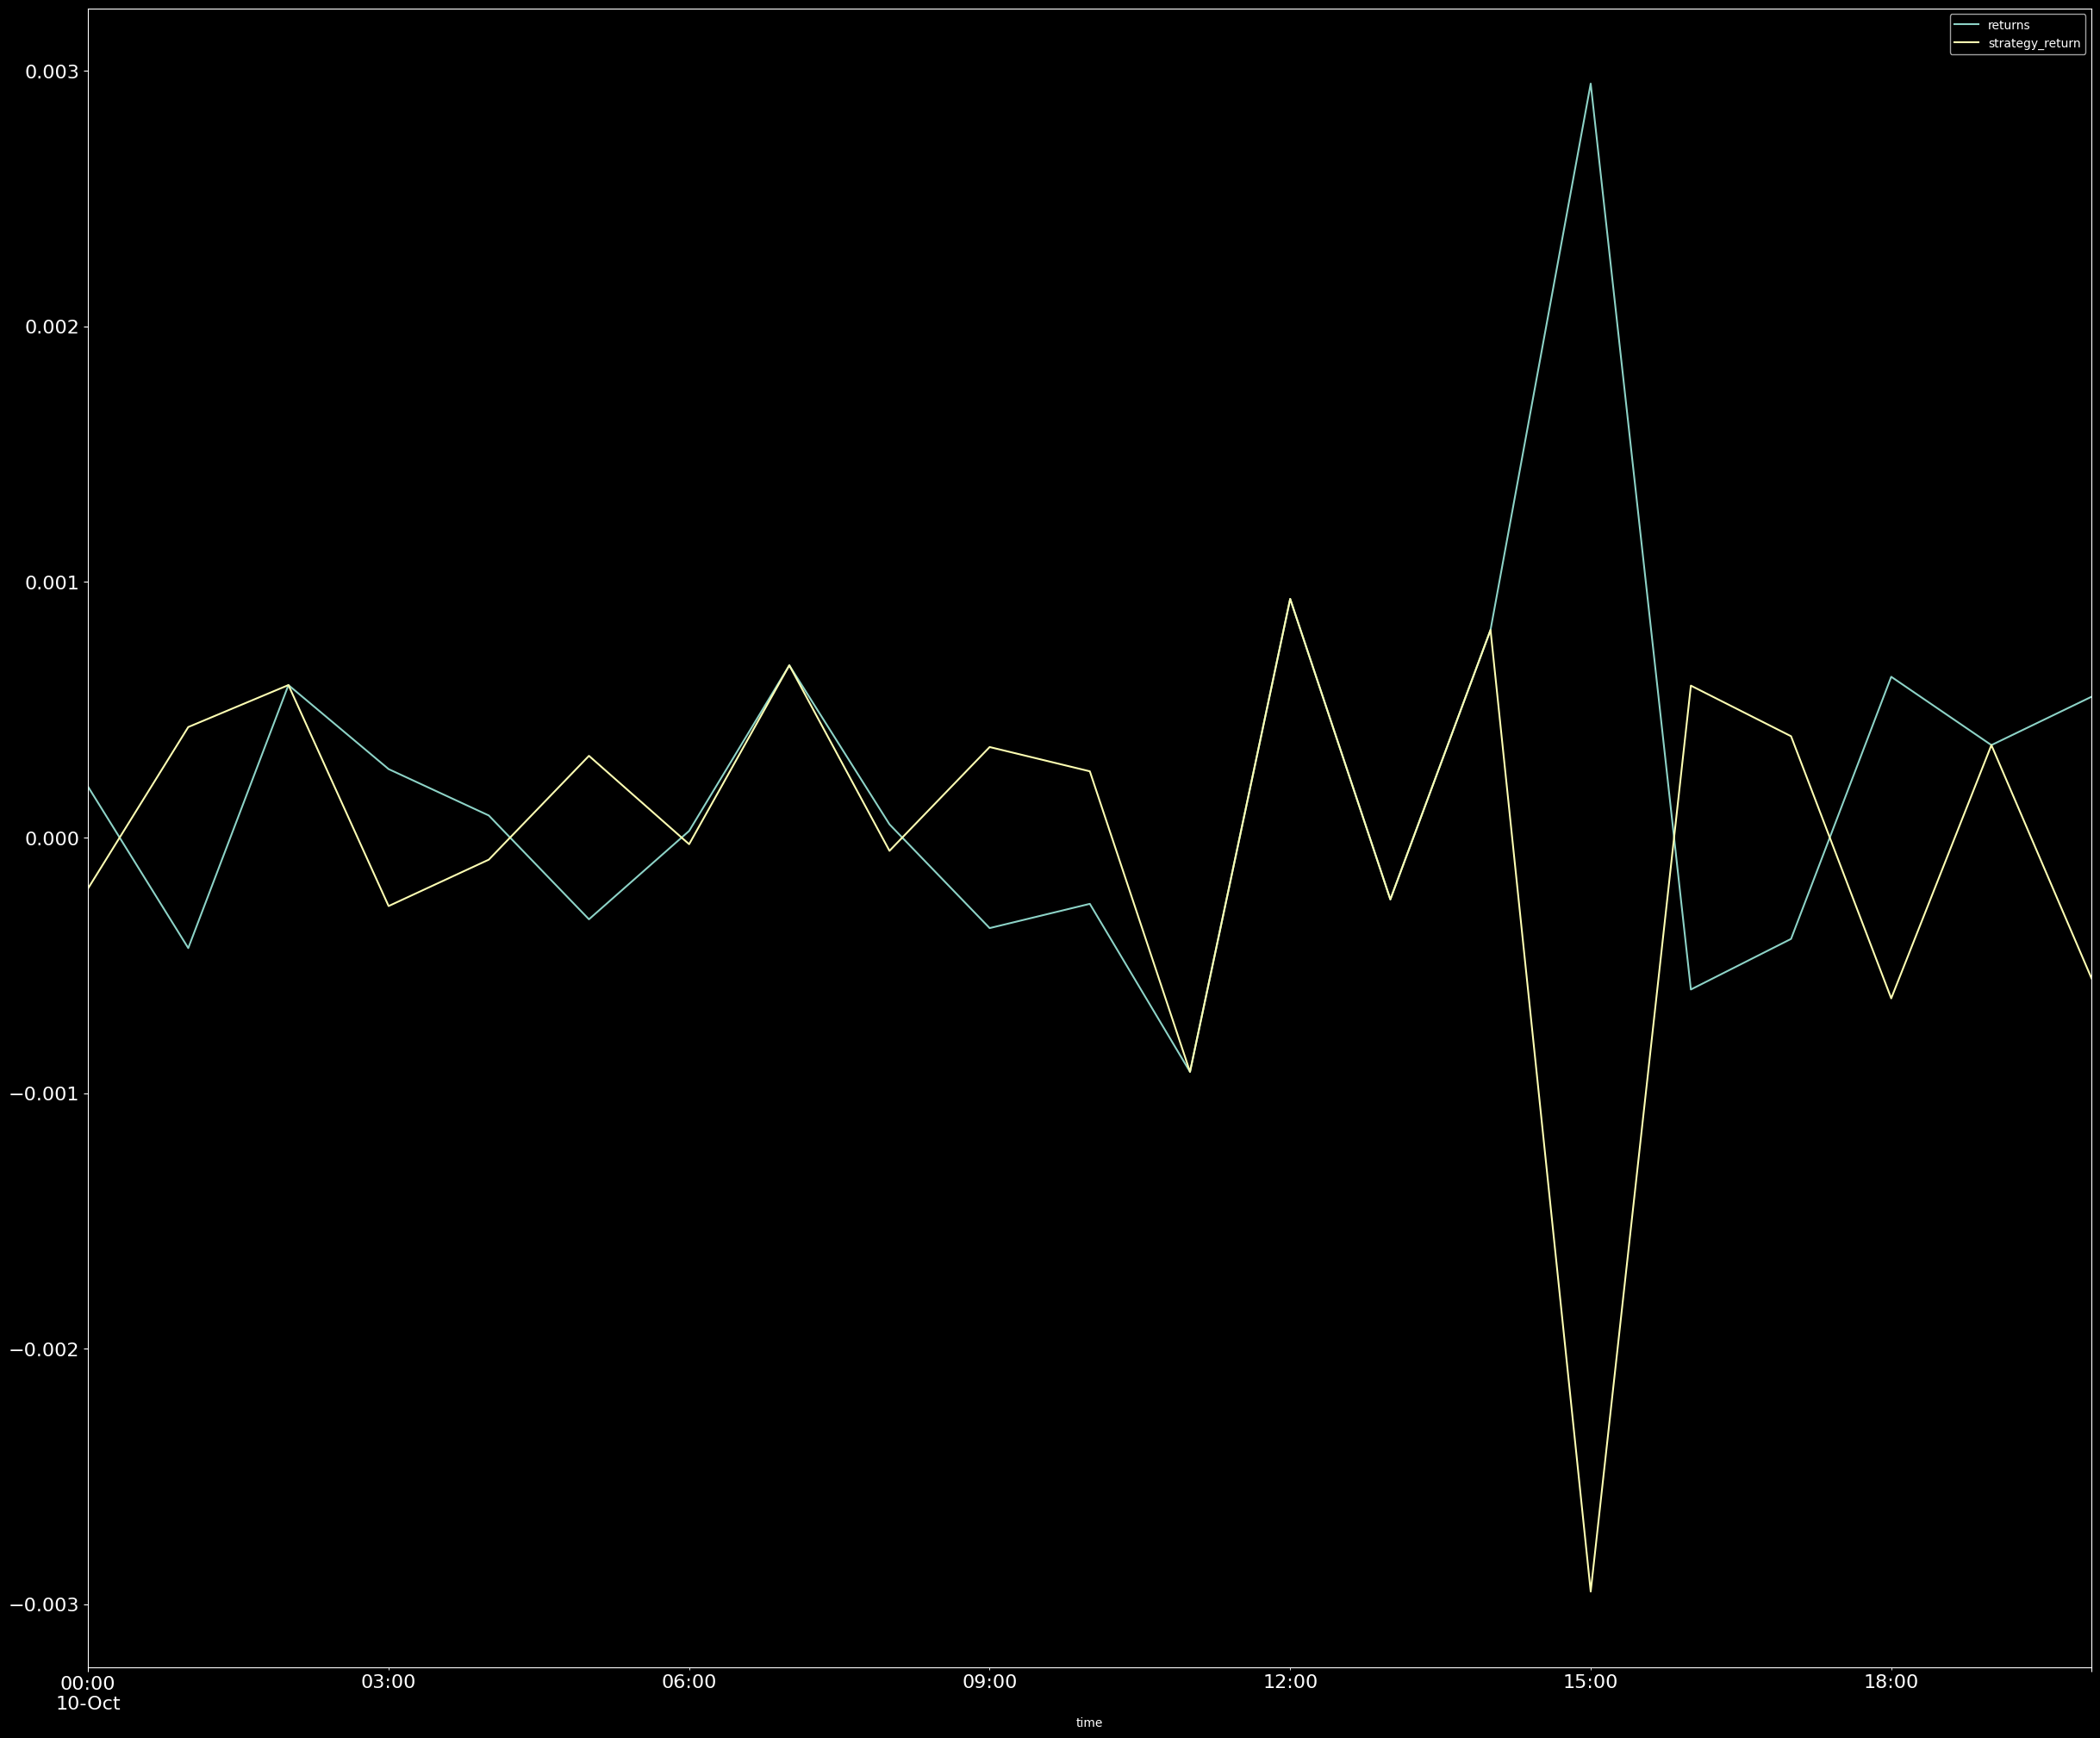

In [139]:
new.plot_results('2025-10-10')